# PolicyGuard AI — Travel Reimbursement Approval Agent

### Objective

Build a practical GenAI and Agentic AI solution that evaluates employee travel
reimbursement claims against the provided policy, receipt requirements,
per-diem limits, and approval rules.

The agent produces one structured recommendation per claim:

- `APPROVE`
- `PARTIAL_APPROVE`
- `REJECT`
- `MANUAL_REVIEW`

### Architecture

```text
Claim JSON
   ↓
Pydantic Validation
   ↓
Llama 3.2 Agent
   ↓
Tool Selection / Policy Context
   ↓
Policy + Receipt + Limit + Approval Tools
   ↓
Deterministic Decision Engine
   ↓
Pydantic Output Validation
   ↓
Final JSON
   ↓
Dashboard
```

The LLM is used for interpretation and tool orchestration. Python is the
authoritative layer for policy enforcement, reimbursement calculations,
deductions, approval thresholds, and the final decision.


## README / Setup

### Prerequisites

- Python 3.11+
- Jupyter Notebook / JupyterLab
- Ollama
- Llama 3.2

### Install Python dependencies

```bash
pip install ollama pydantic pandas matplotlib
```

### Install / prepare the local model

```bash
ollama pull llama3.2
ollama list
```

No external API key or environment variable is required.

### How to run

1. Start Jupyter Lab/Notebook.
2. Select the environment containing the dependencies.
3. Make sure `llama3.2` is available in Ollama.
4. Use **Run All** to execute the notebook top-to-bottom.

### Inputs

The notebook uses the five sample claims supplied in Appendix B of the
assignment. No real employee or company data is used.

### Agent tools

The LLM can call:

1. `policy_lookup`
2. `check_receipt`
3. `check_limit`
4. `check_approval_threshold`

Tool arguments are validated at the Python boundary before business logic
is executed.

### Reliability design

The LLM does not directly determine financial outcomes. The deterministic
decision engine is authoritative for reimbursement calculations and the
final decision. Pydantic validates the final nine-field output contract.

### Why no vector database?

The supplied policy is small, structured, and has stable `POL-*` identifiers.
Deterministic policy lookup provides exact references and predictable
behavior for this prototype. Vector/hybrid retrieval would be appropriate
for a much larger unstructured enterprise policy corpus.

### Scope

This is intentionally a lightweight assignment prototype rather than a
production enterprise reimbursement platform.


## Implementation Strategy

The implementation separates probabilistic AI reasoning from deterministic
business rules:

- **LLM:** claim interpretation, contextual reasoning, and tool selection.
- **Tools:** policy retrieval and validation calculations.
- **Decision engine:** authoritative financial and policy enforcement.
- **Pydantic:** input and output schema validation.
- **Dashboard:** derived directly from actual final claim outcomes.


In [1]:
MODEL_NAME = "llama3.2"

PROJECT_NAME = "Travel Reimbursement Approval Agent"

print(f"Project: {PROJECT_NAME}")
print(f"LLM Model: {MODEL_NAME}")

Project: Travel Reimbursement Approval Agent
LLM Model: llama3.2


In [2]:
import json
from datetime import date, datetime
from typing import List, Literal

import ollama
import pandas as pd
import matplotlib.pyplot as plt

from pydantic import BaseModel, Field

In [3]:
response = ollama.chat(
    model=MODEL_NAME,
    messages=[
        {
            "role": "user",
            "content": "Explain travel reimbursement in one sentence."
        }
    ]
)

print(response["message"]["content"])

Travel reimbursement refers to the process by which an employer compensates employees for their actual expenses incurred while traveling on business, typically by reimbursing them for a set amount or providing a fixed rate per mile driven.


In [4]:
# ============================================================
# Policy Knowledge Base
# ============================================================

POLICY_KB = {
    "POL-CAT-01": {
        "type": "eligibility",
        "description": "Eligible categories are reimbursable when incurred for a documented business purpose.",
        "eligible_categories": [
            "airfare",
            "lodging",
            "meals",
            "ground_transport",
            "conference_fees"
        ]
    },

    "POL-CAT-02": {
        "type": "ineligible",
        "description": "Ineligible expenses are rejected and deducted in full.",
        "ineligible_categories": [
            "alcohol",
            "minibar",
            "spa",
            "gym",
            "personal_entertainment",
            "in_room_movies",
            "personal_shopping",
            "gifts",
            "traffic_fines",
            "penalties",
            "late_fees",
            "personal_expense"
        ]
    },

    "POL-PD-01": {
        "type": "limit",
        "category": "meals",
        "limit": 75.00,
        "unit": "per_day",
        "description": "Meals are reimbursable up to $75 per day."
    },

    "POL-PD-02": {
        "type": "limit",
        "category": "lodging",
        "limit": 200.00,
        "unit": "per_night",
        "description": "Lodging is reimbursable up to $200 per night."
    },

    "POL-PD-03": {
        "type": "limit",
        "category": "ground_transport",
        "limit": 50.00,
        "unit": "per_day",
        "description": "Ground transport is reimbursable up to $50 per day."
    },

    "POL-AIR-01": {
        "type": "airfare_rule",
        "allowed_class": "economy",
        "exception_classes": ["business", "first"],
        "description": (
            "Only economy airfare is reimbursable. "
            "Business/first-class airfare requires Manual Review."
        )
    },

    "POL-RCT-01": {
        "type": "receipt_requirement",
        "threshold": 25.00,
        "always_required": [
            "airfare",
            "lodging"
        ],
        "description": (
            "Any single line item greater than $25 requires "
            "an attached itemized receipt. Airfare and lodging "
            "always require a receipt."
        )
    },

    "POL-RCT-02": {
        "type": "missing_receipt",
        "action": "MANUAL_REVIEW",
        "description": (
            "A missing required receipt routes the claim to "
            "Manual Review rather than silently rejecting it."
        )
    },

    "POL-APR-01": {
        "type": "approval_threshold",
        "max_amount": 500.00,
        "decision": "APPROVE",
        "description": "Total reimbursable amount up to $500 may be auto-approved if fully compliant."
    },

    "POL-APR-02": {
        "type": "approval_threshold",
        "min_amount_exclusive": 500.00,
        "max_amount": 2000.00,
        "decision": "APPROVE",
        "description": "Amounts above $500 and up to $2,000 are within the manager approval tier."
    },

    "POL-APR-03": {
        "type": "approval_threshold",
        "min_amount_exclusive": 2000.00,
        "decision": "MANUAL_REVIEW",
        "description": "Amounts above $2,000 require Manual Review."
    },

    "POL-TIME-01": {
        "type": "timeliness",
        "max_days": 30,
        "decision": "MANUAL_REVIEW",
        "description": "Claims submitted more than 30 days after the expense date require Manual Review."
    }
}

print(f"Loaded {len(POLICY_KB)} policy rules.")

Loaded 12 policy rules.


In [5]:
# ============================================================
# Claim Intake - Appendix B Sample Claims
# ============================================================

claims_json = """
[
    {
        "claim_id": "CLM-001",
        "employee": "A. Rivera",
        "description": "Attend 2-day industry conference (business)",
        "trip_start": "2026-06-10",
        "trip_end": "2026-06-12",
        "submitted_date": "2026-06-20",
        "items": [
            {
                "category": "airfare",
                "description": "Round-trip economy airfare",
                "amount": 420.00,
                "receipt_attached": true
            },
            {
                "category": "lodging",
                "description": "Hotel, 2 nights @ $180",
                "amount": 360.00,
                "receipt_attached": true,
                "nights": 2
            },
            {
                "category": "meals",
                "description": "Meals, 3 days @ ~$60/day",
                "amount": 180.00,
                "receipt_attached": true,
                "days": 3
            },
            {
                "category": "conference_fees",
                "description": "Conference registration",
                "amount": 150.00,
                "receipt_attached": true
            }
        ]
    },

    {
        "claim_id": "CLM-002",
        "employee": "B. Osei",
        "description": "Weekend hotel stay",
        "trip_start": "2026-06-14",
        "trip_end": "2026-06-15",
        "submitted_date": "2026-06-25",
        "items": [
            {
                "category": "spa",
                "description": "Hotel spa package",
                "amount": 300.00,
                "receipt_attached": true
            },
            {
                "category": "minibar",
                "description": "In-room minibar",
                "amount": 80.00,
                "receipt_attached": true
            }
        ]
    },

    {
        "claim_id": "CLM-003",
        "employee": "C. Nakamura",
        "description": "Client site visit (business)",
        "trip_start": "2026-06-08",
        "trip_end": "2026-06-10",
        "submitted_date": "2026-06-22",
        "items": [
            {
                "category": "airfare",
                "description": "Round-trip economy airfare",
                "amount": 300.00,
                "receipt_attached": true
            },
            {
                "category": "lodging",
                "description": "Hotel, 2 nights @ $250",
                "amount": 500.00,
                "receipt_attached": true,
                "nights": 2
            },
            {
                "category": "meals",
                "description": "Meals, 2 days @ $70/day",
                "amount": 140.00,
                "receipt_attached": true,
                "days": 2
            }
        ]
    },

    {
        "claim_id": "CLM-004",
        "employee": "D. Fischer",
        "description": "International vendor negotiation (business)",
        "trip_start": "2026-06-16",
        "trip_end": "2026-06-18",
        "submitted_date": "2026-06-28",
        "items": [
            {
                "category": "airfare",
                "description": "Business-class international airfare",
                "amount": 2400.00,
                "receipt_attached": true,
                "airfare_class": "business"
            },
            {
                "category": "lodging",
                "description": "Hotel, 3 nights",
                "amount": 600.00,
                "receipt_attached": false,
                "nights": 3
            }
        ]
    },

    {
        "claim_id": "CLM-005",
        "employee": "E. Haddad",
        "description": "Client dinner / business development",
        "trip_start": "2026-06-11",
        "trip_end": "2026-06-11",
        "submitted_date": "2026-06-24",
        "items": [
            {
                "category": "meals",
                "description": "Client dinner for 4 (business development)",
                "amount": 220.00,
                "receipt_attached": false,
                "days": 1
            }
        ]
    }
]
"""

claims = json.loads(claims_json)

print(f"Loaded {len(claims)} claims.")

Loaded 5 claims.


In [6]:
# ============================================================
# Pydantic Models - Claim Validation
# ============================================================

class ClaimItem(BaseModel):
    category: str
    description: str
    amount: float = Field(ge=0)
    receipt_attached: bool
    nights: int | None = Field(default=None, ge=1)
    days: int | None = Field(default=None, ge=1)
    airfare_class: str | None = None


class TravelClaim(BaseModel):
    claim_id: str
    employee: str
    description: str
    trip_start: str
    trip_end: str
    submitted_date: str
    items: List[ClaimItem]


# Validate all five claims
validated_claims = [
    TravelClaim(**claim)
    for claim in claims
]

print(f"Successfully validated {len(validated_claims)} claims.")

Successfully validated 5 claims.


## Tool 1 — Policy Lookup

In [7]:
def policy_lookup(category: str) -> dict:
    """
    Retrieve applicable policy rules for an expense category.
    """

    category = category.lower().strip()

    category_policy_map = {
        "airfare": [
            "POL-CAT-01",
            "POL-AIR-01",
            "POL-RCT-01"
        ],
        "lodging": [
            "POL-CAT-01",
            "POL-PD-02",
            "POL-RCT-01"
        ],
        "meals": [
            "POL-CAT-01",
            "POL-PD-01",
            "POL-RCT-01"
        ],
        "ground_transport": [
            "POL-CAT-01",
            "POL-PD-03",
            "POL-RCT-01"
        ],
        "conference_fees": [
            "POL-CAT-01",
            "POL-RCT-01"
        ],
        "spa": [
            "POL-CAT-02",
            "POL-RCT-01"
        ],
        "minibar": [
            "POL-CAT-02",
            "POL-RCT-01"
        ],
        "gym": [
            "POL-CAT-02",
            "POL-RCT-01"
        ],
        "personal_entertainment": [
            "POL-CAT-02",
            "POL-RCT-01"
        ],
        "personal_shopping": [
            "POL-CAT-02",
            "POL-RCT-01"
        ],
        "gifts": [
            "POL-CAT-02",
            "POL-RCT-01"
        ],
        "traffic_fines": [
            "POL-CAT-02",
            "POL-RCT-01"
        ],
        "penalties": [
            "POL-CAT-02",
            "POL-RCT-01"
        ],
        "late_fees": [
            "POL-CAT-02",
            "POL-RCT-01"
        ],
        "alcohol": [
            "POL-CAT-02",
            "POL-RCT-01"
        ]
    }

    policy_refs = category_policy_map.get(category)

    # Unknown categories should not be silently treated as eligible.
    if policy_refs is None:
        return {
            "category": category,
            "status": "UNKNOWN_CATEGORY",
            "policy_refs": [],
            "message": (
                f"No explicit policy mapping was found for category '{category}'. "
                "Manual Review is required."
            )
        }

    return {
        "category": category,
        "status": "FOUND",
        "policy_refs": policy_refs,
        "rules": {
            ref: POLICY_KB[ref]
            for ref in policy_refs
        }
    }

## Tool 2 — Receipt Checker

In [8]:
def check_receipt(item: ClaimItem) -> dict:
    """
    Check whether the expense has the receipt required by policy.
    """

    category = item.category.lower().strip()

    # Receipt is always required for airfare and lodging.
    always_required = category in ["airfare", "lodging"]

    # Any single line item > $25 requires an itemized receipt.
    amount_requires_receipt = item.amount > 25.00

    receipt_required = always_required or amount_requires_receipt

    if receipt_required and not item.receipt_attached:
        return {
            "status": "MANUAL_REVIEW",
            "receipt_required": True,
            "receipt_attached": False,
            "policy_refs": [
                "POL-RCT-01",
                "POL-RCT-02"
            ],
            "message": (
                f"Required receipt is missing for '{item.description}'."
            )
        }

    return {
        "status": "OK",
        "receipt_required": receipt_required,
        "receipt_attached": item.receipt_attached,
        "policy_refs": ["POL-RCT-01"],
        "message": "Receipt requirement satisfied."
    }

## Tool 3 — Per-Diem / Limit Checker

In [9]:
# ============================================================
# Tool 3 - Per-Diem / Limit Checker
# ============================================================

def check_limit(item: ClaimItem) -> dict:
    """
    Calculate the reimbursable amount and deduction
    for categories with per-diem limits.
    """

    category = item.category.lower()
    amount = item.amount

    # Categories with limits
    limits = {
        "meals": {
            "limit": 75.00,
            "quantity": item.days or 1,
            "policy_ref": "POL-PD-01",
            "unit": "day"
        },
        "lodging": {
            "limit": 200.00,
            "quantity": item.nights or 1,
            "policy_ref": "POL-PD-02",
            "unit": "night"
        },
        "ground_transport": {
            "limit": 50.00,
            "quantity": item.days or 1,
            "policy_ref": "POL-PD-03",
            "unit": "day"
        }
    }

    # No per-diem limit for this category
    if category not in limits:
        return {
            "category": category,
            "amount": amount,
            "limit_applies": False,
            "allowed_amount": amount,
            "deducted_amount": 0.00,
            "policy_refs": []
        }

    rule = limits[category]

    maximum_reimbursement = rule["limit"] * rule["quantity"]

    allowed_amount = min(amount, maximum_reimbursement)
    deducted_amount = max(amount - maximum_reimbursement, 0.00)

    return {
        "category": category,
        "amount": amount,
        "limit_applies": True,
        "limit_per_unit": rule["limit"],
        "quantity": rule["quantity"],
        "unit": rule["unit"],
        "maximum_reimbursement": maximum_reimbursement,
        "allowed_amount": round(allowed_amount, 2),
        "deducted_amount": round(deducted_amount, 2),
        "policy_refs": [rule["policy_ref"]]
    }

## Tool 4 — Approval Threshold Checker

In [10]:
def check_approval_threshold(reimbursable_amount: float) -> dict:
    """
    Determines the approval tier based on the reimbursable amount.
    """

    if reimbursable_amount <= 500:
        return {
            "reimbursable_amount": round(reimbursable_amount, 2),
            "tier": "AUTO_APPROVE",
            "decision": "APPROVE",
            "policy_ref": "POL-APR-01",
            "reason": "Reimbursable amount is $500 or less."
        }

    elif reimbursable_amount <= 2000:
        return {
            "reimbursable_amount": round(reimbursable_amount, 2),
            "tier": "MANAGER",
            "decision": "APPROVE",
            "policy_ref": "POL-APR-02",
            "reason": "Reimbursable amount is above $500 and up to $2,000."
        }

    else:
        return {
            "reimbursable_amount": round(reimbursable_amount, 2),
            "tier": "DIRECTOR_MANUAL_REVIEW",
            "decision": "MANUAL_REVIEW",
            "policy_ref": "POL-APR-03",
            "reason": "Reimbursable amount exceeds $2,000."
        }

## Deterministic Decision Engine

In [11]:
def evaluate_claim(claim: TravelClaim) -> dict:
    """
    Deterministic policy enforcement layer.

    The LLM may assist with interpretation and tool selection, but this
    function is authoritative for financial calculations and final decisions.
    """

    policy_refs = set()
    tools_used = set()
    missing_docs = []
    manual_review_reasons = []

    total_amount = 0.0
    total_allowed = 0.0
    total_deducted = 0.0

    # ------------------------------------------------------
    # Timeliness check
    # Assumption: trip_end is used as the expense date for this
    # assignment because individual item dates are not provided.
    # ------------------------------------------------------
    trip_end = datetime.strptime(claim.trip_end, "%Y-%m-%d").date()
    submitted_date = datetime.strptime(
        claim.submitted_date, "%Y-%m-%d"
    ).date()

    days_after_trip = (submitted_date - trip_end).days

    if days_after_trip > POLICY_KB["POL-TIME-01"]["max_days"]:
        policy_refs.add("POL-TIME-01")
        manual_review_reasons.append(
            f"Claim was submitted {days_after_trip} days after the trip end, "
            "exceeding the 30-day submission window."
        )

    for item in claim.items:

        category = item.category.lower().strip()
        total_amount += item.amount

        # --------------------------------------------------
        # 1. Policy lookup
        # --------------------------------------------------
        policy_result = policy_lookup(category)
        tools_used.add("policy_lookup")

        for ref in policy_result.get("policy_refs", []):
            policy_refs.add(ref)

        # Unknown category = ambiguity -> Manual Review.
        if policy_result["status"] == "UNKNOWN_CATEGORY":
            manual_review_reasons.append(
                f"Unknown expense category '{item.category}' requires Manual Review."
            )
            continue

        # --------------------------------------------------
        # 2. Receipt check
        # --------------------------------------------------
        receipt_result = check_receipt(item)
        tools_used.add("check_receipt")

        for ref in receipt_result.get("policy_refs", []):
            policy_refs.add(ref)

        if receipt_result["status"] == "MANUAL_REVIEW":
            manual_review_reasons.append(
                f"Required receipt is missing for {item.description}."
            )
            missing_docs.append(
                f"Itemized receipt for {item.description}"
            )

        # --------------------------------------------------
        # 3. Ineligible categories
        # --------------------------------------------------
        ineligible_categories = POLICY_KB[
            "POL-CAT-02"
        ]["ineligible_categories"]

        if category in ineligible_categories:
            policy_refs.add("POL-CAT-02")
            total_deducted += item.amount
            continue

        # --------------------------------------------------
        # 4. Airfare class exception
        # --------------------------------------------------
        if category == "airfare":
            policy_refs.add("POL-AIR-01")

            if item.airfare_class:
                airfare_class = item.airfare_class.lower().strip()

                if airfare_class in ["business", "first"]:
                    manual_review_reasons.append(
                        f"{item.airfare_class.title()}-class airfare requires Manual Review."
                    )

        # --------------------------------------------------
        # 5. Per-diem / category limit
        # --------------------------------------------------
        limit_result = check_limit(item)
        tools_used.add("check_limit")

        for ref in limit_result.get("policy_refs", []):
            policy_refs.add(ref)

        total_allowed += limit_result["allowed_amount"]
        total_deducted += limit_result["deducted_amount"]

    # ------------------------------------------------------
    # Final decision precedence
    # ------------------------------------------------------
    if manual_review_reasons:
        decision = "MANUAL_REVIEW"
        # The claim is unresolved, so do not represent pending amounts as zero.
        approved_amount = None
        deducted_amount = None

    elif total_allowed == 0 and total_amount > 0:
        decision = "REJECT"
        approved_amount = 0.0
        deducted_amount = round(total_deducted, 2)

    else:
        approval_result = check_approval_threshold(total_allowed)
        tools_used.add("check_approval_threshold")
        policy_refs.add(approval_result["policy_ref"])

        if approval_result["decision"] == "MANUAL_REVIEW":
            decision = "MANUAL_REVIEW"
            # A reviewer must resolve the case before amounts can be finalized.
            approved_amount = None
            deducted_amount = None
            manual_review_reasons.append(
                approval_result["reason"]
            )

        elif total_deducted > 0:
            decision = "PARTIAL_APPROVE"
            approved_amount = round(total_allowed, 2)
            deducted_amount = round(total_deducted, 2)

        else:
            decision = "APPROVE"
            approved_amount = round(total_allowed, 2)
            deducted_amount = 0.0

    # ------------------------------------------------------
    # Explanation
    # ------------------------------------------------------
    if decision == "APPROVE":
        explanation = (
            f"The claim is fully compliant with the applicable policy rules. "
            f"The reimbursable amount is ${approved_amount:.2f}."
        )

    elif decision == "PARTIAL_APPROVE":
        explanation = (
            f"The claim is partially approved because some eligible expenses "
            f"exceed applicable policy limits. "
            f"${approved_amount:.2f} is reimbursable and "
            f"${deducted_amount:.2f} is deducted."
        )

    elif decision == "REJECT":
        explanation = (
            f"The claim is rejected because all submitted expenses are "
            f"ineligible under the travel reimbursement policy. "
            f"The total rejected amount is ${deducted_amount:.2f}."
        )

    else:
        explanation = (
            "A reviewer needs to resolve the following issue(s) before the "
            "reimbursable and deducted amounts can be finalized: "
            + " ".join(manual_review_reasons)
            + " No final approved or deducted amount is reported while this "
            "claim is pending review."
        )

    # Prototype confidence indicator; this is not a calibrated probability.

    confidence = {
        "APPROVE": 0.98,
        "PARTIAL_APPROVE": 0.95,
        "REJECT": 0.98,
        "MANUAL_REVIEW": 0.85
    }[decision]

    return {
        "claim_id": claim.claim_id,
        "decision": decision,
        "approved_amount": (
            round(approved_amount, 2) if approved_amount is not None else None
        ),
        "deducted_amount": (
            round(deducted_amount, 2) if deducted_amount is not None else None
        ),
        "missing_docs": missing_docs,
        "policy_refs": sorted(policy_refs),
        "confidence": confidence,
        "explanation": explanation,
        "tools_used": sorted(tools_used)
    }


## Agentic AI Workflow

In [12]:
AGENT_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "policy_lookup",
            "description": "Retrieve applicable travel reimbursement policy rules for an expense category.",
            "parameters": {
                "type": "object",
                "properties": {
                    "category": {
                        "type": "string",
                        "description": "Expense category such as airfare, lodging, meals, ground_transport, or conference_fees."
                    }
                },
                "required": ["category"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "check_receipt",
            "description": "Check whether an expense has the receipt required by travel reimbursement policy.",
            "parameters": {
                "type": "object",
                "properties": {
                    "category": {
                        "type": "string"
                    },
                    "description": {
                        "type": "string"
                    },
                    "amount": {
                        "type": "number"
                    },
                    "receipt_attached": {
                        "type": "boolean"
                    }
                },
                "required": [
                    "category",
                    "description",
                    "amount",
                    "receipt_attached"
                ]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "check_limit",
            "description": "Calculate the reimbursable amount and deduction for expenses subject to per-day or per-night limits.",
            "parameters": {
                "type": "object",
                "properties": {
                    "category": {
                        "type": "string"
                    },
                    "amount": {
                        "type": "number"
                    },
                    "quantity": {
                        "type": "integer"
                    }
                },
                "required": [
                    "category",
                    "amount",
                    "quantity"
                ]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "check_approval_threshold",
            "description": "Determine the approval tier based on the total reimbursable amount.",
            "parameters": {
                "type": "object",
                "properties": {
                    "reimbursable_amount": {
                        "type": "number"
                    }
                },
                "required": ["reimbursable_amount"]
            }
        }
    }
]

print(f"Configured {len(AGENT_TOOLS)} agent tools.")

Configured 4 agent tools.


In [13]:
def execute_tool_call(tool_name: str, arguments: dict) -> dict:
    """
    Execute an LLM-selected tool safely.

    Invalid or incomplete tool arguments are returned as a tool error
    instead of crashing the complete agent workflow.
    """

    try:

        # --------------------------------------------------
        # Policy Lookup
        # --------------------------------------------------
        if tool_name == "policy_lookup":

            if "category" not in arguments:
                return {
                    "status": "TOOL_ERROR",
                    "tool": tool_name,
                    "message": "Missing required argument: category"
                }

            return policy_lookup(
                str(arguments["category"])
            )

        # --------------------------------------------------
        # Receipt Check
        # --------------------------------------------------
        elif tool_name == "check_receipt":

            required = [
                "category",
                "description",
                "amount",
                "receipt_attached"
            ]

            missing = [
                field for field in required
                if field not in arguments
            ]

            if missing:
                return {
                    "status": "TOOL_ERROR",
                    "tool": tool_name,
                    "missing_arguments": missing,
                    "message": (
                        "Required arguments are missing."
                    )
                }

            item = ClaimItem(
                category=str(arguments["category"]),
                description=str(arguments["description"]),
                amount=float(arguments["amount"]),
                receipt_attached=bool(
                    arguments["receipt_attached"]
                )
            )

            return check_receipt(item)

        # --------------------------------------------------
        # Limit Check
        # --------------------------------------------------
        elif tool_name == "check_limit":

            required = [
                "category",
                "amount",
                "quantity"
            ]

            missing = [
                field for field in required
                if field not in arguments
            ]

            if missing:
                return {
                    "status": "TOOL_ERROR",
                    "tool": tool_name,
                    "missing_arguments": missing,
                    "message": (
                        "Required arguments are missing."
                    )
                }

            category = str(arguments["category"])
            amount = float(arguments["amount"])
            quantity = int(arguments["quantity"])

            if category.lower() == "lodging":

                item = ClaimItem(
                    category=category,
                    description="Agent tool evaluation",
                    amount=amount,
                    receipt_attached=True,
                    nights=quantity
                )

            elif category.lower() in [
                "meals",
                "ground_transport"
            ]:

                item = ClaimItem(
                    category=category,
                    description="Agent tool evaluation",
                    amount=amount,
                    receipt_attached=True,
                    days=quantity
                )

            else:

                item = ClaimItem(
                    category=category,
                    description="Agent tool evaluation",
                    amount=amount,
                    receipt_attached=True
                )

            return check_limit(item)

        # --------------------------------------------------
        # Approval Threshold
        # --------------------------------------------------
        elif tool_name == "check_approval_threshold":

            if "reimbursable_amount" not in arguments:
                return {
                    "status": "TOOL_ERROR",
                    "tool": tool_name,
                    "missing_arguments": [
                        "reimbursable_amount"
                    ],
                    "message": (
                        "Missing required argument: "
                        "reimbursable_amount"
                    )
                }

            reimbursable_amount = float(
                arguments["reimbursable_amount"]
            )

            return check_approval_threshold(
                reimbursable_amount
            )

        else:

            return {
                "status": "TOOL_ERROR",
                "tool": tool_name,
                "message": f"Unknown tool: {tool_name}"
            }

    except (ValueError, TypeError, KeyError) as exc:

        return {
            "status": "TOOL_ERROR",
            "tool": tool_name,
            "message": str(exc)
        }

In [14]:
def run_agent(claim: TravelClaim) -> dict:
    """
    Run the LLM agent for one travel reimbursement claim.

    The LLM is responsible for deciding which tools are useful.
    Python remains responsible for executing tools and enforcing
    the final reimbursement decision.
    """

    claim_json = claim.model_dump_json(indent=2)

    system_prompt = """
You are a Travel Reimbursement Policy Agent.

Your job is to analyze the COMPLETE employee travel reimbursement claim
and gather policy evidence before a deterministic Python policy engine
makes the final decision.

AVAILABLE TOOLS:
- policy_lookup
- check_receipt
- check_limit
- check_approval_threshold

MANDATORY WORKFLOW:

1. Inspect EVERY expense item in the claim.
2. For EVERY item, use policy_lookup to identify the applicable policies.
3. For EVERY item, use check_receipt to determine whether the required
   receipt is present.
4. For EVERY item that may have a per-day or per-night limit, use
   check_limit.
5. Pay special attention to airfare_class.
6. After determining the reimbursable amount, use
   check_approval_threshold when appropriate.
7. Do not stop after evaluating only one expense item.
8. Do not invent policy rules.
9. Do not make final financial calculations yourself when a tool can
   perform them.
10. Do not make the final approval/rejection decision yourself.
    The deterministic Python policy engine makes the final decision.

IMPORTANT POLICY RULES:

- Airfare: only economy is reimbursable.
- Business/first-class airfare requires Manual Review.
- Airfare and lodging always require receipts.
- Any single line item greater than $25 requires an itemized receipt.
- Missing required receipts require Manual Review.
- Meals: maximum $75 per day.
- Lodging: maximum $200 per night.
- Ground transport: maximum $50 per day.
- Amounts above $2,000 require Manual Review.
- Ineligible expenses are rejected/deducted in full when there is
  nothing else reimbursable.

When you finish gathering evidence, summarize:
- policies found
- receipt findings
- limit findings
- approval-threshold finding
- any ambiguity or Manual Review trigger

Do not assume that a receipt is optional merely because an item is
below $25 when another policy makes the receipt mandatory.
"""

    messages = [
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": (
                "Evaluate the following travel reimbursement claim. "
                "Use the available tools to gather relevant policy context.\n\n"
                + claim_json
            )
        }
    ]

    tool_calls_log = []

    # Allow several rounds of tool calls.
    for _ in range(5):

        response = ollama.chat(
            model=MODEL_NAME,
            messages=messages,
            tools=AGENT_TOOLS
        )

        assistant_message = response["message"]

        messages.append(assistant_message)

        tool_calls = assistant_message.get("tool_calls", [])

        # No more tool calls means the agent has finished gathering context.
        if not tool_calls:
            return {
                "agent_summary": assistant_message.get("content", ""),
                "tool_calls": tool_calls_log,
                "messages": messages
            }

        for tool_call in tool_calls:

            function = tool_call["function"]

            tool_name = function["name"]

            arguments = function.get("arguments", {})

            # Ollama may return arguments as a JSON string.
            if isinstance(arguments, str):
                arguments = json.loads(arguments)

            tool_result = execute_tool_call(
                tool_name,
                arguments
            )

            tool_calls_log.append({
                "tool": tool_name,
                "arguments": arguments,
                "result": tool_result
            })

            messages.append({
                "role": "tool",
                "content": json.dumps(tool_result)
            })

    return {
        "agent_summary": "Agent reached the maximum tool-call iterations.",
        "tool_calls": tool_calls_log,
        "messages": messages
    }

## Complete Claim Processing Workflow

In [15]:
def process_claim(claim: TravelClaim) -> dict:
    """
    Complete Travel Reimbursement Agent workflow.

    The LLM performs tool orchestration and contextual reasoning.
    The deterministic policy engine is the authoritative source
    for the final reimbursement decision and amounts.
    """

    # ---------------------------------------------
    # 1. Agentic tool orchestration
    # ---------------------------------------------
    agent_result = run_agent(claim)

    # ---------------------------------------------
    # 2. Deterministic policy enforcement
    # ---------------------------------------------
    final_result = evaluate_claim(claim)

    # ---------------------------------------------
    # 3. Keep agent evidence for audit/debugging
    # ---------------------------------------------
    final_result["_agent_evidence"] = {
        "summary": agent_result["agent_summary"],
        "tool_calls": agent_result["tool_calls"]
    }

    return final_result

In [16]:
from typing import Optional, Literal
from pydantic import BaseModel, Field

Decision = Literal[
    "APPROVE",
    "PARTIAL_APPROVE",
    "REJECT",
    "MANUAL_REVIEW"
]


class ReimbursementResult(BaseModel):
    claim_id: str
    decision: Decision
    approved_amount: Optional[float] = Field(default=None, ge=0)
    deducted_amount: Optional[float] = Field(default=None, ge=0)
    missing_docs: List[str]
    policy_refs: List[str]
    confidence: float = Field(ge=0, le=1)
    explanation: str
    tools_used: List[str]

In [17]:
def format_final_result(result: dict) -> dict:
    """
    Convert the internal result into the exact output contract
    required by the assignment.
    """

    validated = ReimbursementResult(
        claim_id=result["claim_id"],
        decision=result["decision"],
        approved_amount=result["approved_amount"],
        deducted_amount=result["deducted_amount"],
        missing_docs=result["missing_docs"],
        policy_refs=result["policy_refs"],
        confidence=result["confidence"],
        explanation=result["explanation"],
        tools_used=result["tools_used"]
    )

    return validated.model_dump()

In [18]:
final_results = []
agent_audit = {}

for claim in validated_claims:
    print(f"Processing {claim.claim_id}...")

    processed = process_claim(claim)

    agent_audit[claim.claim_id] = processed["_agent_evidence"]

    final_results.append(
        format_final_result(processed)
    )

print(f"\nProcessed {len(final_results)} claims.")


Processing CLM-001...
Processing CLM-002...
Processing CLM-003...
Processing CLM-004...
Processing CLM-005...

Processed 5 claims.


## Agent Audit Trail

The following trace shows the actual tools selected by the LLM for one of
the supplied claims. The trace is taken from the same end-to-end execution
used to produce the final results.


In [19]:
audit_claim_id = "CLM-003"

print(f"Agent tool calls for {audit_claim_id}:\n")

for call in agent_audit[audit_claim_id]["tool_calls"]:
    print(
        f"- {call['tool']}: "
        f"{json.dumps(call['arguments'])}"
    )

Agent tool calls for CLM-003:

- policy_lookup: {"category": "airfare"}
- policy_lookup: {"category": "lodging"}
- policy_lookup: {"category": "meals"}
- check_receipt: {"category": "airfare", "amount": 300, "receipt_attached": true}
- check_receipt: {"category": "lodging", "amount": 500, "receipt_attached": true}
- check_receipt: {"category": "meals", "amount": 140, "receipt_attached": true}
- check_limit: {"quantity": 2, "category": "lodging", "amount": 500}
- check_limit: {"amount": 140, "quantity": 2, "category": "meals"}
- check_approval_threshold: {"reimbursable_amount": "check_limit", "category": "lodging", "amount": 500, "quantity": 2}
- check_approval_threshold: {"reimbursable_amount": "check_limit", "category": "meals", "amount": 140, "quantity": 2}


## Evaluation / Test Results

In [20]:
expected_results = {
    "CLM-001": {
        "decision": "APPROVE",
        "approved_amount": 1110.0,
        "deducted_amount": 0.0
    },
    "CLM-002": {
        "decision": "REJECT",
        "approved_amount": 0.0,
        "deducted_amount": 380.0
    },
    "CLM-003": {
        "decision": "PARTIAL_APPROVE",
        "approved_amount": 840.0,
        "deducted_amount": 100.0
    },
    "CLM-004": {
        "decision": "MANUAL_REVIEW"
    },
    "CLM-005": {
        "decision": "MANUAL_REVIEW"
    }
}

evaluation_rows = []

for result in final_results:
    expected = expected_results[result["claim_id"]]

    decision_match = result["decision"] == expected["decision"]

    approved_match = (
        "approved_amount" not in expected
        or result["approved_amount"] == expected["approved_amount"]
    )

    deducted_match = (
        "deducted_amount" not in expected
        or result["deducted_amount"] == expected["deducted_amount"]
    )

    evaluation_rows.append({
        "claim_id": result["claim_id"],
        "decision_match": decision_match,
        "approved_amount_match": approved_match,
        "deducted_amount_match": deducted_match,
        "passed": (
            decision_match
            and approved_match
            and deducted_match
        )
    })

evaluation_df = pd.DataFrame(evaluation_rows)

display(evaluation_df)

assert evaluation_df["passed"].all(), (
    "One or more assignment expectations did not pass."
)

print(
    f"Passed: {evaluation_df['passed'].sum()}/"
    f"{len(evaluation_df)}"
)


,claim_id,decision_match,approved_amount_match,deducted_amount_match,passed
0,CLM-001,True,True,True,True
1,CLM-002,True,True,True,True
2,CLM-003,True,True,True,True
3,CLM-004,True,True,True,True
4,CLM-005,True,True,True,True


Passed: 5/5


## Sample Outputs

The following examples are generated from the actual final results.


In [21]:
sample_outputs = pd.DataFrame(final_results)[
    [
        "claim_id",
        "decision",
        "approved_amount",
        "deducted_amount",
        "explanation"
    ]
].head(3)

display(sample_outputs)

,claim_id,decision,approved_amount,deducted_amount,explanation
0,CLM-001,APPROVE,1110.0,0.0,The claim is fully compliant with the applicab...
1,CLM-002,REJECT,0.0,380.0,The claim is rejected because all submitted ex...
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,The claim is partially approved because some e...


## Dashboard

The dashboard below summarizes actual final claim outcomes generated by the
agent workflow.


In [22]:
dashboard_df = pd.DataFrame(final_results)

display(
    dashboard_df[
        [
            "claim_id",
            "decision",
            "approved_amount",
            "deducted_amount",
            "confidence"
        ]
    ]
)


,claim_id,decision,approved_amount,deducted_amount,confidence
0,CLM-001,APPROVE,1110.0,0.0,0.98
1,CLM-002,REJECT,0.0,380.0,0.98
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,0.95
3,CLM-004,MANUAL_REVIEW,NaN,NaN,0.85
4,CLM-005,MANUAL_REVIEW,NaN,NaN,0.85


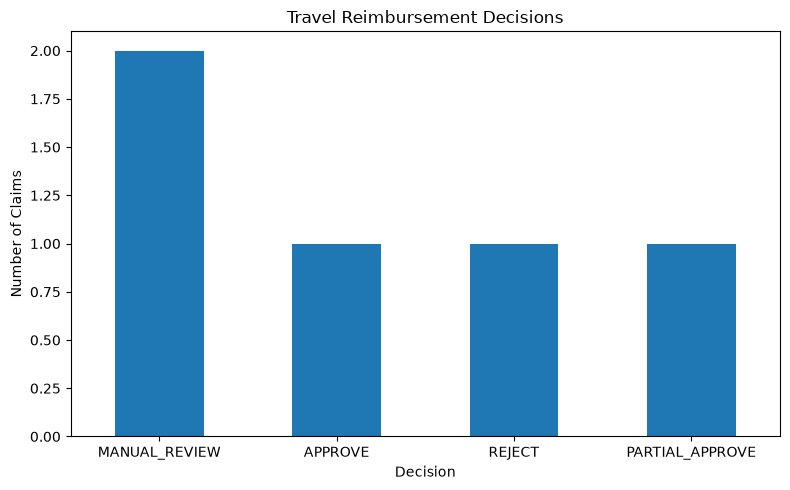

In [23]:
decision_counts = dashboard_df["decision"].value_counts()

plt.figure(figsize=(8, 5))
decision_counts.plot(kind="bar")

plt.title("Travel Reimbursement Decisions")
plt.xlabel("Decision")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


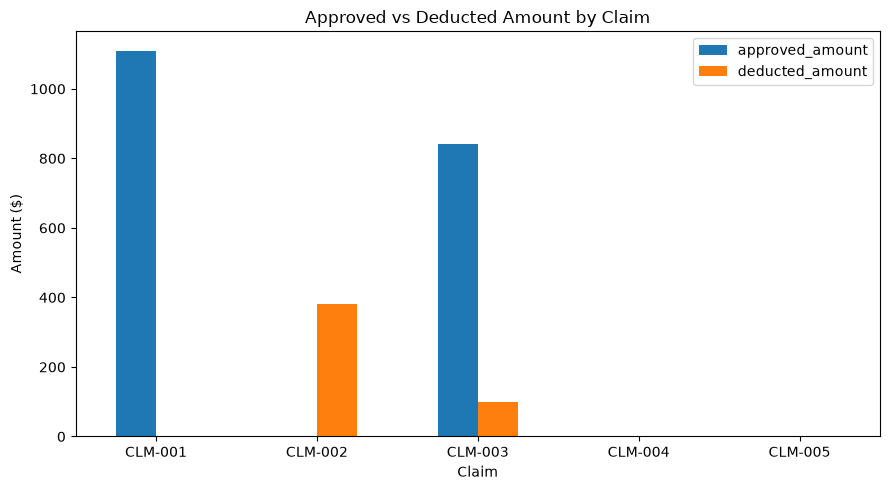

In [24]:
amount_summary = dashboard_df[
    ["claim_id", "approved_amount", "deducted_amount"]
].set_index("claim_id")

# Manual-review amounts are intentionally null until a reviewer decides the claim.
# Matplotlib leaves those unresolved values blank rather than treating them as zero.

amount_summary.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Approved vs Deducted Amount by Claim")
plt.xlabel("Claim")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Design Notes & Reasoning

### 1. Solution Approach

The solution uses a hybrid Agentic AI + deterministic policy architecture.

The Llama 3.2 local model acts as the reasoning and orchestration layer.
It analyzes the claim and decides which tools are useful for retrieving
policy context and validating claim information.

Python performs authoritative policy enforcement, financial calculations,
deductions, approval thresholds, and the final decision.

### 2. Why a Deterministic Decision Engine?

Financial reimbursement decisions should be predictable and auditable.

The LLM can interpret claim descriptions and select relevant tools, but it
can produce incorrect reasoning or malformed tool arguments. Therefore:

- The LLM performs reasoning and orchestration.
- Python performs reimbursement calculations.
- Python applies policy limits and approval thresholds.
- Python determines the final decision.
- Pydantic validates the final output structure.

### 3. Manual Review Strategy

Manual Review is used for uncertainty, incomplete information, policy
exceptions, and high-value claims.

Examples:

- Missing required receipts.
- Business or first-class airfare.
- Claims above $2,000.
- Unknown expense categories.
- Claims submitted more than 30 days after the expense date.

For the supplied claims:

- **CLM-004:** Manual Review because of business-class airfare, missing
  lodging receipt, and a claim above $2,000.
- **CLM-005:** Manual Review because the meal/client dinner is above the
  $25 receipt threshold and the required receipt is missing.

### 4. Manual Review Amount Assumption

For Manual Review cases, `approved_amount` and `deducted_amount` are both
reported as `null`. A pending claim has not received a final financial
decision, so reporting zero could be mistaken for a confirmed amount. The
reviewer must resolve the exception or missing information before either
amount is finalized.

### 5. Confidence Score Note

The `confidence` value is a rule-based prototype indicator, not a calibrated
probability. It reflects confidence in the deterministic policy outcome based
on the available claim information.

For a production system, confidence should be calibrated using historical
labeled reimbursement claims and evaluated using appropriate calibration and
classification metrics.

### 6. Timeliness Assumption

The supplied claim structure contains trip dates but not individual expense
dates. For the 30-day timeliness rule, the prototype uses `trip_end` as the
expense-date proxy.

A production system should validate timeliness against each actual expense
date.

### 7. Why Vector RAG Was Not Used

The supplied policy is small, structured, and has stable `POL-*` identifiers.
Deterministic lookup provides exact policy references, predictable retrieval,
and lower complexity.

For a larger enterprise policy corpus, the architecture could evolve to:

```text
Document Ingestion
→ Chunking
→ Embeddings
→ Vector / Hybrid Retrieval
→ Policy Context
→ Agent
```

### 8. LLM Tool-Calling Reliability

LLM-generated tool arguments are treated as untrusted input.

The tool router:

- validates required arguments,
- converts numeric values to expected types,
- handles missing arguments,
- returns structured tool errors instead of crashing.

The deterministic engine remains independent of LLM reasoning errors.

### 9. Output Validation

The final result is validated using Pydantic.

The required output contains exactly:

- `claim_id`
- `decision`
- `approved_amount`
- `deducted_amount`
- `missing_docs`
- `policy_refs`
- `confidence`
- `explanation`
- `tools_used`

Allowed decisions are:

- `APPROVE`
- `PARTIAL_APPROVE`
- `REJECT`
- `MANUAL_REVIEW`

### 10. Key Trade-offs

**Local LLM vs hosted LLM:** A local Ollama model avoids API keys and
external service dependencies. The trade-off is potentially weaker
reasoning/tool-calling quality than larger hosted models.

**Deterministic rules vs LLM decision making:** Deterministic rules make
financial outcomes predictable and auditable, while the LLM remains useful
for interpretation and orchestration.

**Structured lookup vs vector RAG:** Structured lookup is appropriate for
the small supplied policy. Retrieval infrastructure can be added when the
policy corpus becomes large and unstructured.

### 11. Current Limitations / Next Improvements

Potential production improvements include:

- enterprise document ingestion,
- hybrid/vector policy retrieval,
- stronger Pydantic schemas for tool arguments,
- persistent audit logging,
- automated evaluation datasets,
- receipt OCR/image validation,
- duplicate-claim detection,
- human approval workflow integration,
- monitoring and observability,
- model/version management,
- production API deployment.

The prototype intentionally avoids these components because the assignment
prioritizes a small, working, well-explained solution.


## Final Submission Output

The next cell is intentionally the final code cell. It outputs the required JSON array with exactly the nine assignment fields.

In [25]:
# Final output required by the assignment.
# This must remain the final code cell in the notebook.

final_json = final_results

print(json.dumps(final_json, indent=2))


[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01"
    ],
    "confidence": 0.98,
    "explanation": "The claim is fully compliant with the applicable policy rules. The reimbursable amount is $1110.00.",
    "tools_used": [
      "check_approval_threshold",
      "check_limit",
      "check_receipt",
      "policy_lookup"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02",
      "POL-RCT-01"
    ],
    "confidence": 0.98,
    "explanation": "The claim is rejected because all submitted expenses are ineligible under the travel reimbursement policy. The total rejected amount is $380.00.",
    "tools_used": [
      "check_recei